# 컨볼루션 신경망

## CIFAR-10 살펴보기
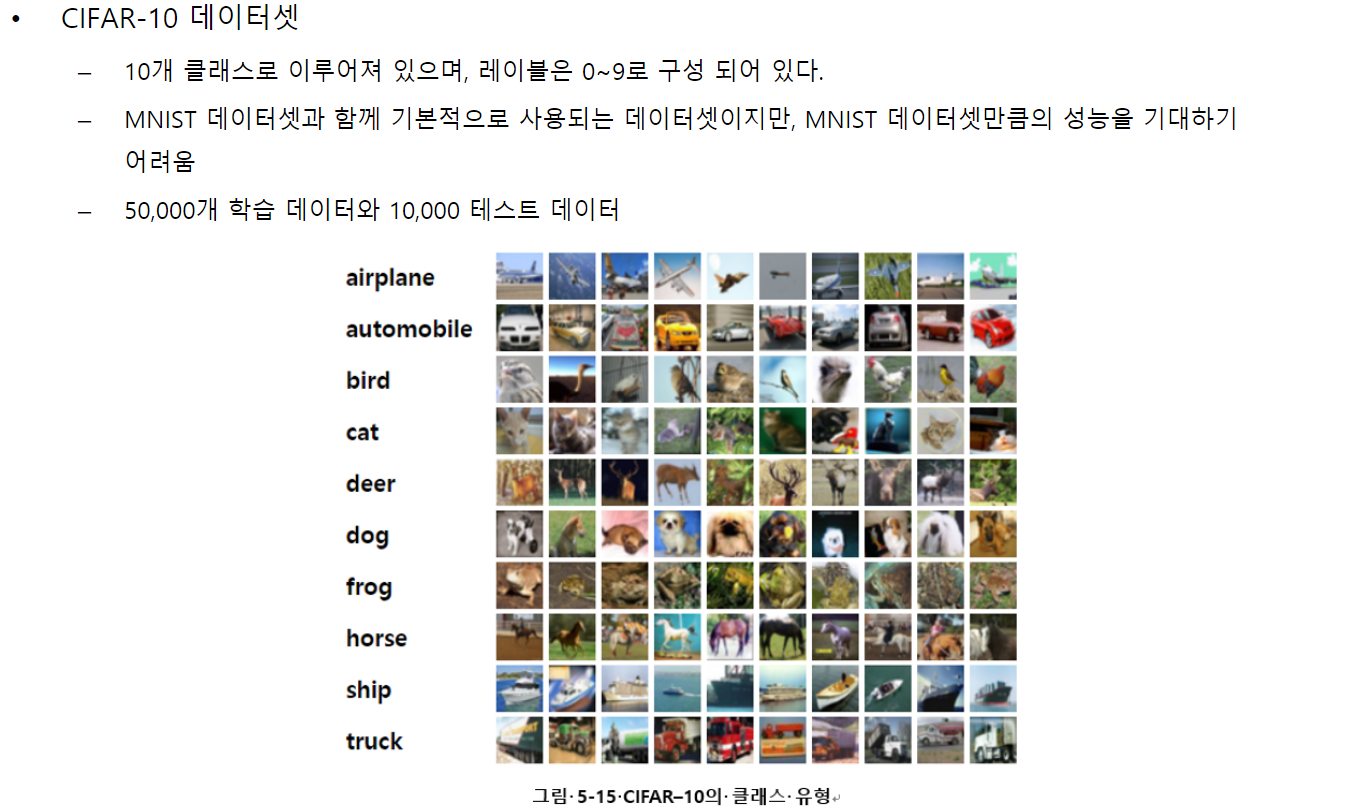

### 데이터 다운로드

In [1]:
from  tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


### 데이터 그려보기

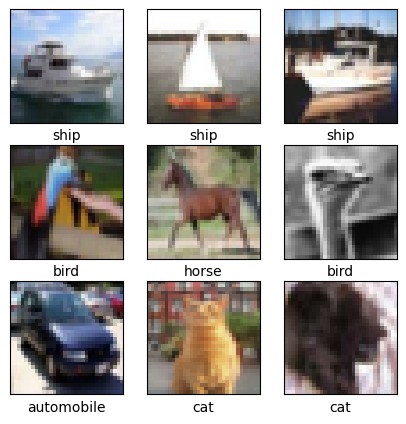

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # 데이터를 동일하게 유지

# 이미지 클래스 정의
class_names = ['airplane', 'automobile', 'bird', 'cat','deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# x_train에서 무작위로 9개 추출해 화면에 출력
sample_size = 9
random_idx = np.random.randint(50000, size=sample_size)

# 이미지 출력
plt.figure(figsize=(5,5))

for i, idx in enumerate(random_idx):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx])
    plt.xlabel(class_names[y_train[idx][0]])

plt.show()



### 전처리

In [3]:
x_train.shape

(50000, 32, 32, 3)

- 채널별 평균과 표준편차를 이용해 정규화

In [4]:
# 정규화를 위한 평균과 표준편차는 채널별로 계산
x_mean = np.mean(x_train, axis=(0,1,2))
x_std = np.std(x_train, axis=(0,1,2))

x_train = (x_train - x_mean) / x_std
x_test = (x_test - x_mean) / x_std

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                  test_size = 0.3, random_state = 777)

print(x_train.shape, len(y_train))
print(x_val.shape, len(y_val))

(35000, 32, 32, 3) 35000
(15000, 32, 32, 3) 15000


## 신경망 학습시키기

### 모델 구성
- Conv2D, MaxPool2D

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam

model = Sequential()
# (32, 32, 3)의 데이터를 입력으로 받습니다.
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu',
                 ))
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))

model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))

model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = (2, 2), strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(10, activation = 'softmax')) # 10개의 출력을 가지는 신경망

In [65]:
model.inputs

[<KerasTensor shape=(None, 32, 32, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_261>]

- Adam(0.0001), sparse_categorical_crossentropy
- sparse_categorical_crossentropy는 0~9 형태로 되어있는 레이블을 그대로 사용할 수 있게 해줌


In [7]:
model.compile(optimizer=Adam(0.0001),
              loss = 'sparse_categorical_crossentropy',
              metrics =['acc'])

### 모델 학습하기

In [8]:
history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(x_val, y_val))

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - acc: 0.4127 - loss: 1.6262 - val_acc: 0.5291 - val_loss: 1.3266
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.5648 - loss: 1.2385 - val_acc: 0.5755 - val_loss: 1.2026
Epoch 3/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.6244 - loss: 1.0650 - val_acc: 0.6207 - val_loss: 1.0603
Epoch 4/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.6717 - loss: 0.9437 - val_acc: 0.6558 - val_loss: 0.9668
Epoch 5/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.7088 - loss: 0.8431 - val_acc: 0.6737 - val_loss: 0.9104
Epoch 6/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.7369 - loss: 0.7569 - val_acc: 0.6855 - val_loss: 0.9011
Epoch 7/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.7682 - loss: 0.6772 - val_acc: 0.7069 - val_loss: 0.8458
Epoch 8/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.7926 - loss: 0.6076 - val_acc: 0.7200 - val_loss: 0.8057
Epoch 9/30
1094/1094 ━━━━━━━━━━━━━━━━━

In [10]:
model.save('cifar10_model.h5')

### 학습 과정 그리기

In [12]:
hist_data = history.history
hist_data.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

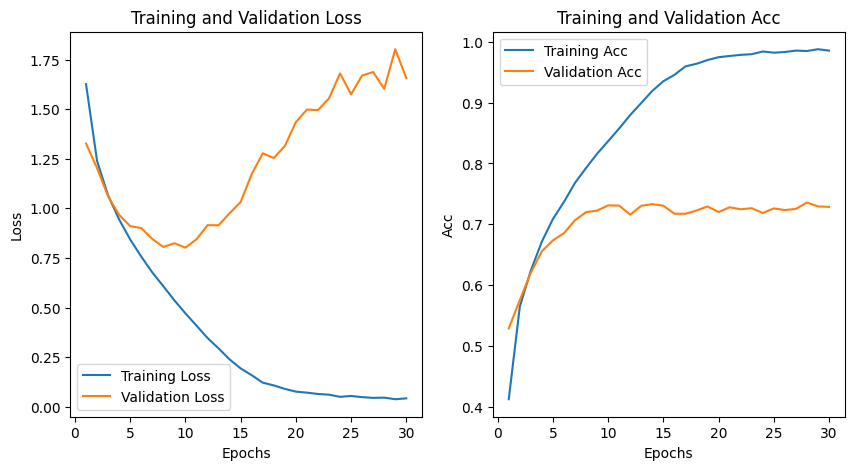

In [14]:
import matplotlib.pyplot as plt

# Loss 데이터 추출
loss = hist_data['loss']
val_loss = hist_data['val_loss']

# X축 값 생성
epochs = range(1, len(loss)+1)

# 차트 크기 설정
fig = plt.figure(figsize=(10, 5))

# Loss 기준 차트 생성
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, label='Training Loss')
ax1.plot(epochs, val_loss, label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# 훈련 및 검증 정화도
acc = hist_data['acc']
val_acc = hist_data['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, label='Training Acc')
ax2.plot(epochs, val_acc, label='Validation Acc')
ax2.set_title('Training and Validation Acc')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Acc')
ax2.legend()

plt.show()

- 과대적합 문제 발생!




- 예방할 수 있는 방법을 알아보자   
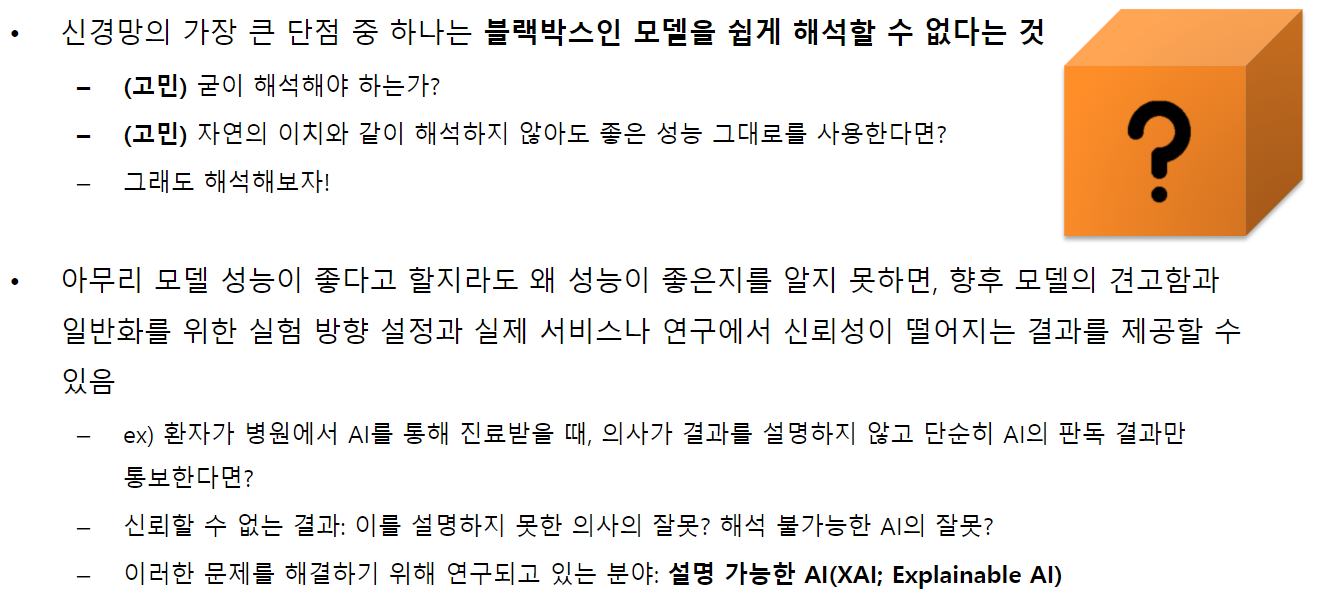


### 신경망 시각화해보기

In [64]:
import tensorflow as tf

# model.build(input_shape=(None, 32, 32, 3))

get_layer_name = [ layer.name  for layer in model.layers]
get_output = [ layer.output  for layer in model.layers]

In [56]:
print('층 이름', get_layer_name)
print('출력 층 이름', get_output)

층 이름 ['conv2d_18', 'conv2d_19', 'max_pooling2d_9', 'conv2d_20', 'conv2d_21', 'max_pooling2d_10', 'conv2d_22', 'conv2d_23', 'max_pooling2d_11', 'flatten_3', 'dense_6', 'dense_7']
출력 층 이름 [<KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_262>, <KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_264>, <KerasTensor shape=(None, 16, 16, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_267>, <KerasTensor shape=(None, 16, 16, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_271>, <KerasTensor shape=(None, 16, 16, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_276>, <KerasTensor shape=(None, 8, 8, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_282>, <KerasTensor shape=(None, 8, 8, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_289>, <KerasTensor shape=(None, 8, 8, 128), dtype=float32, sparse=False, ragged=

In [66]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/tmp/ipykernel_6196/3086034495.py:20: RuntimeWarning: invalid value encountered in divide
  x -= x.mean(); x /= x.std()
/tmp/ipykernel_6196/3086034495.py:22: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')


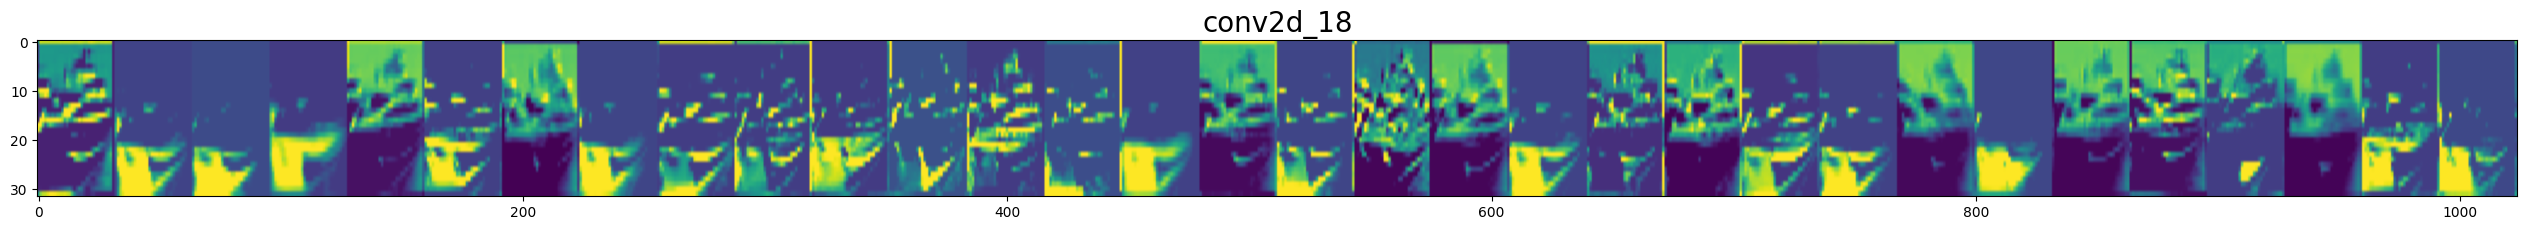

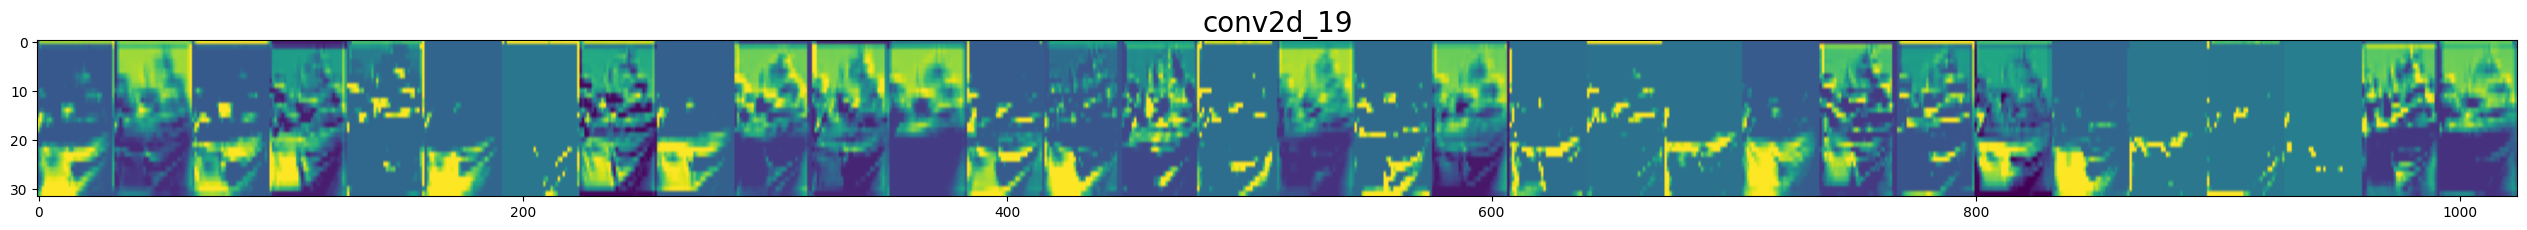

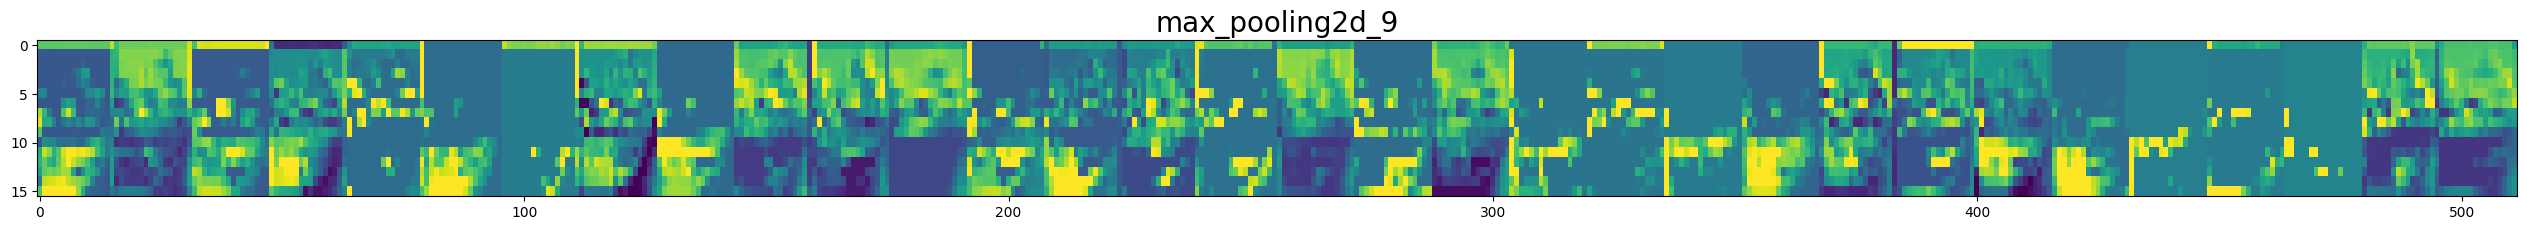

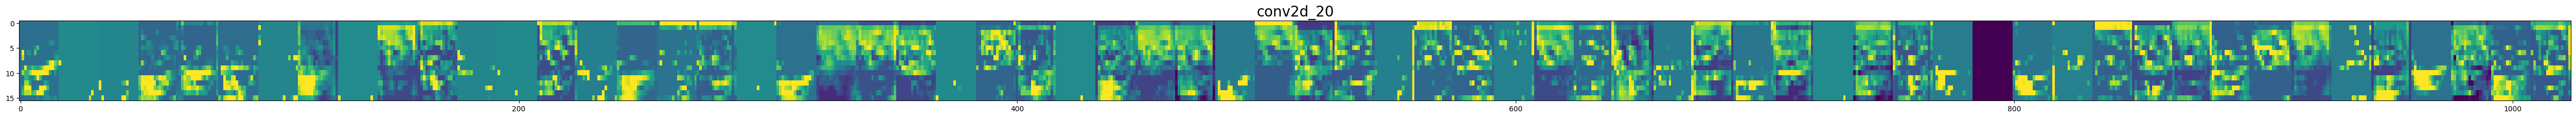

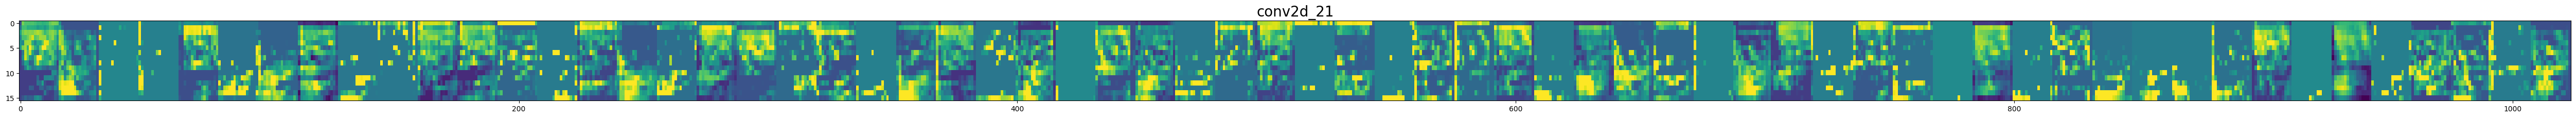

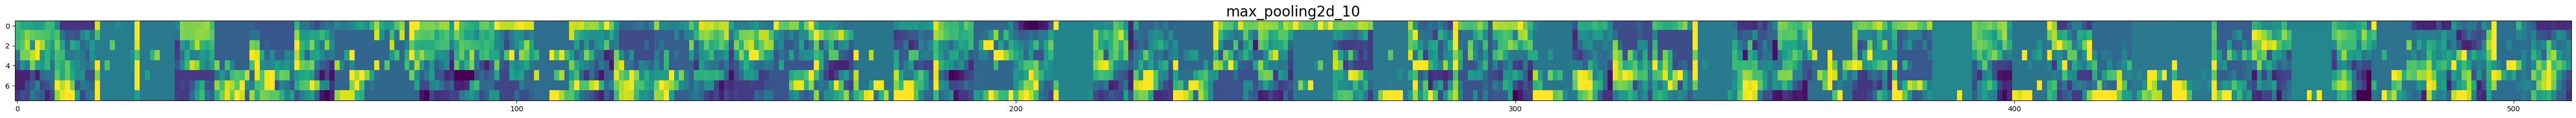

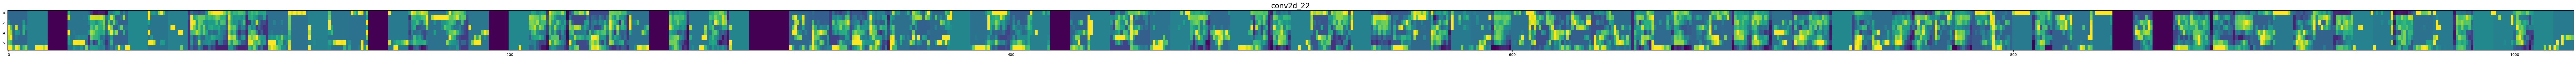

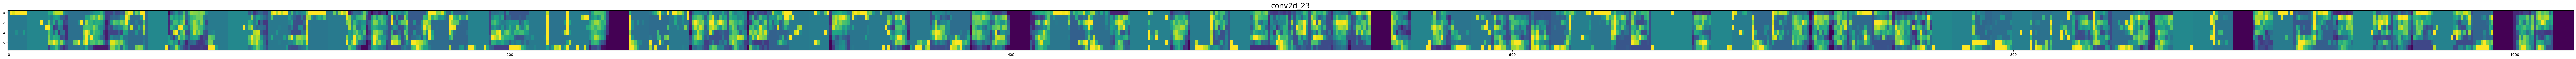

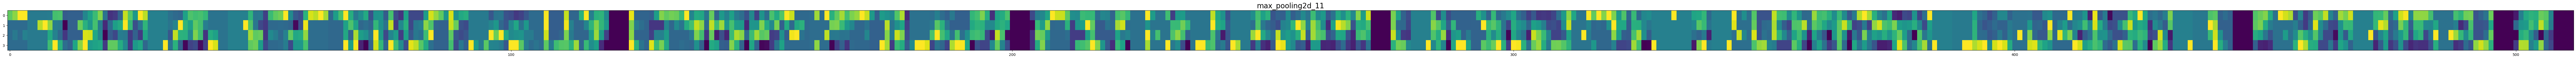

In [63]:
# 모델 전체에서 output을 가져올 수 있습니다.
visual_model = tf.keras.models.Model(inputs = model.inputs, outputs = get_output)

# 테스트셋의 두 번째 데이터는 '배'입니다.
test_img = np.expand_dims(x_test[1], axis = 0) #  expand_dims는 axis로 지정된 차원을 추가
feature_maps = visual_model.predict(test_img)

for layer_name, feature_map in zip(get_layer_name, feature_maps):
    # Dense 층은 제외합니다.
    if(len(feature_map.shape) == 4):
        img_size = feature_map.shape[1]
        features = feature_map.shape[-1]

        # (img_size, img_size)의 feature_map이 features 개수만큼 존재합니다.
        display_grid = np.zeros((img_size, img_size * features))

        # 각 특징맵을 display_grid 배열에 이어붙입니다.
        for i in range(features):
            x = feature_map[0, :, :, i]
            x -= x.mean(); x /= x.std()
            x *= 64; x += 128
            x = np.clip(x, 0, 255).astype('uint8')
            display_grid[:, i * img_size : (i + 1) * img_size] = x

        plt.figure(figsize = (features, 2 + 1./features))
        plt.title(layer_name, fontsize = 20)
        plt.grid(False)
        plt.imshow(display_grid, aspect = 'auto', cmap = 'viridis')